# Project 8 — eval noise & energy regression

Adapted from `chreissel/neutrino_project/notebooks/eval-noise.ipynb` for the
current TimeSeriesPhysics layout.

- Model: `tasks.Project8.project8_regression.Project8Regression`
  (encoder = `models.s4d.S4Model`, output = [mu, log_var] for energy_eV).
- DataModule: `dataloader.project8_dataloader.Project8DataModule`.
  Yields `(X, var)` — `X` is the time series when `freq_transform=None`,
  the FFT (real/imag) when `freq_transform='fft'`.

We instantiate the DataModule manually here (Lightning DataModules aren't
saved in checkpoints), so adjust the `data_kwargs` block to match the run
you're evaluating.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
# Make src/ packages importable when running the notebook in-place.
_repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.join(_repo_root, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, 'src'))

import numpy as np
import torch
from scipy import signal
import matplotlib.pyplot as plt

from tasks.Project8.project8_regression import Project8Regression
from dataloader.project8_dataloader import Project8DataModule

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CHECKPOINT = '/n/home03/creissel/TimeSeriesPhysics/checkpoints/project8_s4d_regression_energy_gaussiannll/best.ckpt'

In [4]:
from models.s4d import S4Model
encoder = S4Model(
    d_input=2,
    d_output=2,
    d_model=128,
    n_layers=6,
    dropout=0.0,
    prenorm=False,
)
model = Project8Regression.load_from_checkpoint(
    CHECKPOINT, encoder=encoder, map_location=device,
)
model = model.to(device).eval()

In [5]:
dm = Project8DataModule.load_from_checkpoint(CHECKPOINT)
dm.setup('test')
print('mu  =', dm.mu)
print('std =', dm.stds)

mu  = [18549.906]
std = [28.833803]


In [6]:
energy_ind = dm.hparams.variables.index('energy_eV')

In [8]:
# Inference loop. The model output is (mu, log_var) per event for energy_eV.
# We also compute simple PSD-derived event features (max / summed power)
# straight from the time series, mirroring the upstream notebook.
max_powers = []
summed_powers = []
true_z = []
pred_mu_z = []
pred_logvar = []

ts_loader = iter(dm.test_dataloader())
with torch.no_grad():
    for x, var in dm.test_dataloader():
        out = model(x.to(device)).cpu().numpy()
        pred_mu_z.append(out[:, 0])
        pred_logvar.append(out[:, 1])
        true_z.append(var.numpy()[:, 0])

true_z = np.concatenate(true_z)
pred_mu_z = np.concatenate(pred_mu_z)
pred_logvar = np.concatenate(pred_logvar)
max_powers = np.asarray(max_powers)
summed_powers = np.asarray(summed_powers)

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [9]:
# Undo z-score normalisation (single target, so mu/stds are scalars).
mu0, std0 = float(dm.mu[energy_ind]), float(dm.stds[energy_ind])
pred_energy = pred_mu_z * std0 + mu0
true_energy = true_z * std0 + mu0
pred_sigma = np.exp(0.5 * pred_logvar) * std0  # in eV
energy_errs = true_energy - pred_energy

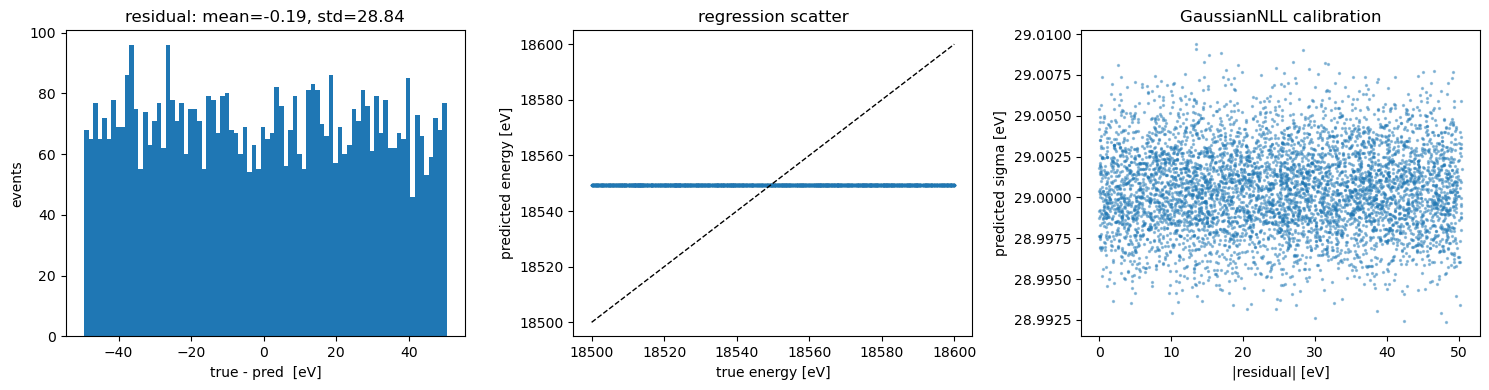

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(energy_errs, bins=80)
axes[0].set_xlabel('true - pred  [eV]')
axes[0].set_ylabel('events')
axes[0].set_title(f'residual: mean={energy_errs.mean():.2f}, std={energy_errs.std():.2f}')

axes[1].scatter(true_energy, pred_energy, s=2, alpha=0.4)
lo, hi = true_energy.min(), true_energy.max()
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[1].set_xlabel('true energy [eV]')
axes[1].set_ylabel('predicted energy [eV]')
axes[1].set_title('regression scatter')

axes[2].scatter(np.abs(energy_errs), pred_sigma, s=2, alpha=0.4)
axes[2].set_xlabel('|residual| [eV]')
axes[2].set_ylabel('predicted sigma [eV]')
axes[2].set_title('GaussianNLL calibration')

fig.tight_layout()